In [86]:
from jarvis.db.figshare import data
import pandas as pd
df=pd.read_csv('Li_min.csv')

In [87]:
df['jid'] = df['name'].apply(lambda x:x.split('_')[1])

In [88]:
df

,Unnamed: 0,name,avg_voltage,voltage_profile,max_voltage,max_vol_cap,vol_capacity_profile,max_grav_cap,grav_capacity_profile,jid
0,0,Li_JVASP-47127_Li3SiNi3O8.json,4.177388,3.9146358966827393;3.6190178394317627;3.843556...,4.869210,41.897990,41.89799024944064;41.897990249440625;41.897990...,10.059754,9.491042424708008;9.514428636219353;9.53793038...,JVASP-47127
1,1,Li_JVASP-50689_Li4Ti3Cu3Te2O16.json,3.897832,4.1367247104644775;4.0855467319488525;4.102619...,4.685204,35.873462,35.873461807075365;35.87346180707537;35.873461...,7.909171,7.673409281698393;7.688688596552545;7.70402888...,JVASP-50689
2,2,Li_JVASP-48119_LiMn2F5.json,3.581894,3.212631940841675;3.650526762008667;3.33120942...,4.025076,51.179342,51.179341670156504;51.17934167015651;51.179341...,16.283925,15.817002552000238;15.882059584757009;15.94765...,JVASP-48119
3,3,Na_JVASP-1495_NaLi2Sb.json,1.309156,0.6242127418518066;0.5436215400695801;1.179081...,2.081828,70.772426,70.77242630596444;70.77242630596444;70.7724263...,24.186317,21.119257418263402;21.508905707124807;21.91320...,JVASP-1495
4,4,Ca_JVASP-102282_Li2CaAl.json,1.565666,0.602760910987854;0.42831504344940186;1.683864...,2.809159,67.362540,67.3625395189022;67.3625395189022;67.362539518...,73.031284,41.39018392885959;44.1209832128054;47.23757574...,JVASP-102282
...,...,...,...,...,...,...,...,...,...,...
7469,7469,Li_JVASP-111973_Li2VCrO4.json,3.076996,1.8755977153778076;1.897601842880249;2.1608316...,4.173770,38.885634,38.88563428310146;38.88563428310145;38.8856342...,10.008379,9.26401130572448;9.286290762609413;9.308677639...,JVASP-111973
7470,7470,Ca_JVASP-95309_Li2Ca2Ta3O10.json,7.241006,3.3240036964416504;3.366443157196045;3.4171195...,12.708701,23.825662,23.825661927271902;23.825661927271902;23.82566...,4.129305,3.7370227222114485;3.758023358614465;3.7792613...,JVASP-95309
7471,7471,Na_JVASP-136942_NaLiP.json,1.800342,0.5294408798217773;1.1752333641052246;1.821949...,2.754673,98.287835,98.2878348264949;98.2878348264949;98.287834826...,82.135566,55.00715791961167;57.731145975924704;60.738977...,JVASP-136942
7472,7472,Li_JVASP-144254_LiMn3CrO8.json,4.263947,4.240626573562622;4.285734415054321;4.20915341...,4.376711,42.044738,42.04473845484511;42.0447384548451;42.04473845...,9.691774,9.524432479717637;9.547983733012797;9.57165174...,JVASP-144254


In [89]:
dft_3d_df = pd.DataFrame(data('dft_3d'))

Obtaining 3D dataset 76k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


In [92]:
df_new= pd.merge(df,dft_3d_df, on='jid')

In [93]:
df_new_max_vol = df_new[df_new['max_voltage']<=5.5]

In [94]:
df_new_max_vol_ehull = df_new_max_vol[df_new_max_vol['ehull']<=0.05]

In [97]:
'JVASP-2017' in df_new.jid.values #LiCoCO2 should exists= :)

True

In [98]:
import numpy as np
df_new_max_vol_ehull['min_voltage']=df_new_max_vol_ehull['voltage_profile'].apply(lambda x:np.min(np.array(x.split(';'),dtype='float')))

/tmp/ipykernel_291847/919404216.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_max_vol_ehull['min_voltage']=df_new_max_vol_ehull['voltage_profile'].apply(lambda x:np.min(np.array(x.split(';'),dtype='float')))


In [99]:
df_new_max_vol_ehull_min_vol = df_new_max_vol_ehull[df_new_max_vol_ehull['min_voltage']>1]

In [100]:
df_new_max_vol_ehull_min_vol

,Unnamed: 0,name,avg_voltage,voltage_profile,max_voltage,max_vol_cap,vol_capacity_profile,max_grav_cap,grav_capacity_profile,jid,...,poisson,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search,min_voltage
2,2,Li_JVASP-48119_LiMn2F5.json,3.581894,3.212631940841675;3.650526762008667;3.33120942...,4.025076,51.179342,51.179341670156504;51.17934167015651;51.179341...,16.283925,15.817002552000238;15.882059584757009;15.94765...,JVASP-48119,...,na,"[OPT-LOPTICS,JVASP-48119.zip,https://ndownload...",16,na,na,na,na,mp-763331,-F-Li-Mn,3.212632
15,15,Li_JVASP-42175_LiVF4.json,4.330079,3.6442487239837646;3.631939649581909;3.8410894...,5.154451,42.169496,42.16949561206411;42.16949561206411;42.1694956...,13.151501,12.512258908890612;12.552935473261204;12.59387...,JVASP-42175,...,na,"[OPT-LOPTICS,JVASP-42175.zip,https://ndownload...",12,na,na,na,na,mp-780539,-F-Li-V,3.631940
20,20,Li_JVASP-119357_Li2Mn3TeO8.json,3.282684,3.0047123432159424;3.054805040359497;3.0539267...,3.891480,36.671350,36.67135006280895;36.67135006280895;36.6713500...,7.952453,7.714142328303391;7.729584452449287;7.74508852...,JVASP-119357,...,na,[],14,na,na,na,na,mp-755971,-Li-Mn-O-Te,3.004712
37,37,Li_JVASP-140321_LiNd2RuO6.json,2.894476,2.7797048091888428;2.804586172103882;2.8118584...,3.126359,45.968590,45.968589939548835;45.968589939548835;45.96858...,6.887461,6.802525222042231;6.814530420419332;6.82657806...,JVASP-140321,...,na,[],20,na,na,na,na,mp-1211080,-Li-Nd-O-Ru,2.779705
40,40,Li_JVASP-111963_LiVF4.json,3.981115,3.625145673751831;3.618274450302124;3.62022519...,4.495332,42.367363,42.367362858371756;42.367362858371756;42.36736...,13.151501,12.512258908890612;12.552935473261204;12.59387...,JVASP-111963,...,na,[],24,na,na,na,na,mp-757195,-F-Li-V,3.601448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7450,7450,Li_JVASP-119591_LiCo2P2O8.json,4.435289,4.246318101882935;4.393021821975708;4.47881484...,4.623000,66.287588,66.28758795767037;66.28758795767037;66.2875879...,21.645913,21.287904411299998;21.405917452781978;21.52524...,JVASP-119591,...,na,[],26,na,na,na,na,mp-1176782,-Co-Li-O-P,4.246318
7452,7452,Li_JVASP-43192_Li2Co3WO8.json,3.860573,4.173327207565308;4.232928991317749;4.25491452...,5.062396,41.878579,41.8785792116586;41.87857921165859;41.87857921...,6.844063,6.666812473017969;6.678343027901987;6.68991353...,JVASP-43192,...,na,"[OPT-LOPTICS,JVASP-43192.zip,https://ndownload...",28,na,na,na,na,mp-775180,-Co-Li-O-W,2.781467
7456,7456,Li_JVASP-119318_Li2CoNi3O8.json,4.452673,4.997974395751953;4.84534215927124;4.457109212...,4.997974,42.754733,42.75473284008914;42.754732840089154;42.754732...,9.206936,8.889012394004919;8.909522655328447;8.93012778...,JVASP-119318,...,na,[],14,na,na,na,na,mp-752703,-Co-Li-Ni-O,4.179734
7463,7463,Li_JVASP-1843_LiHoSe2.json,1.983914,1.3704659938812256;1.4175755977630615;1.388835...,3.253549,61.346177,61.34617662270898;61.346176622708974;61.346176...,10.349087,10.158500139236196;10.185295924451077;10.21223...,JVASP-1843,...,0.25,"[FD-ELAST,JVASP-1843.zip,https://ndownloader.f...",4,46.76,28.97,2.203,na,mp-15796,-Ho-Li-Se,1.370466


In [106]:
!pwd

/mnt/c/Users/knc6/OneDrive - NIST/KamalLaptop/JARVIS-ALIGNN-Bands/pmg_grad3


In [102]:
df_new_max_vol_ehull_min_vol_gap = df_new_max_vol_ehull_min_vol[df_new_max_vol_ehull_min_vol['optb88vdw_bandgap']<0.1]

In [103]:
'JVASP-2017' in df_new_max_vol_ehull_min_vol_gap.jid.values

False

(array([ 22.,  72.,  94.,  99., 179., 231., 300., 293.,  98.,  18.]),
 array([1.10532224, 1.51806217, 1.93080211, 2.34354204, 2.75628197,
        3.1690219 , 3.58176184, 3.99450177, 4.4072417 , 4.81998163,
        5.23272157]),
 <BarContainer object of 10 artists>)

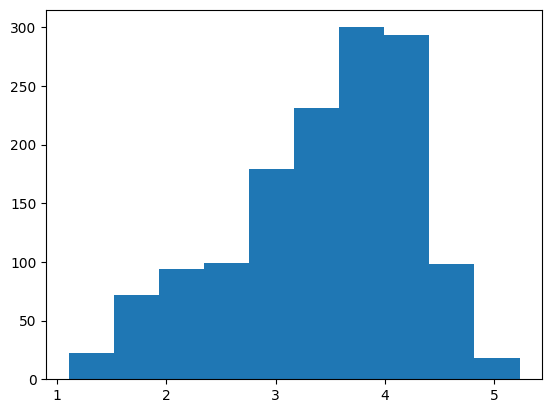

In [66]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(df_new_max_vol_ehull_min_vol['avg_voltage'])

In [67]:
df_new_max_vol_ehull_min_vol['optb88vdw_bandgap']


2       1.923
15      0.168
20      0.000
37      0.293
40      0.047
        ...  
7450    0.000
7452    0.013
7456    0.000
7463    1.599
7465    0.428
Name: optb88vdw_bandgap, Length: 1406, dtype: float64

(array([1.254e+03, 1.110e+02, 2.900e+01, 3.000e+00, 1.000e+00, 1.000e+00,
        5.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([  1.69535794,  18.65043662,  35.60551531,  52.56059399,
         69.51567268,  86.47075136, 103.42583005, 120.38090873,
        137.33598742, 154.2910661 , 171.24614479]),
 <BarContainer object of 10 artists>)

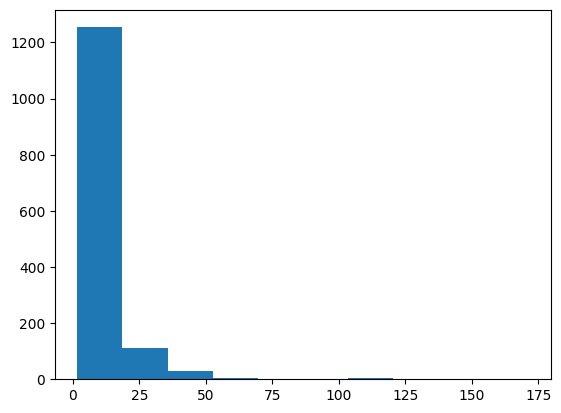

In [68]:
plt.hist(df_new_max_vol_ehull_min_vol['max_grav_cap'])

(array([1.263e+03, 1.100e+02, 2.000e+01, 7.000e+00, 0.000e+00, 1.000e+00,
        3.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([ 13.78432423,  65.39995334, 117.01558245, 168.63121156,
        220.24684067, 271.86246978, 323.47809889, 375.093728  ,
        426.70935711, 478.32498621, 529.94061532]),
 <BarContainer object of 10 artists>)

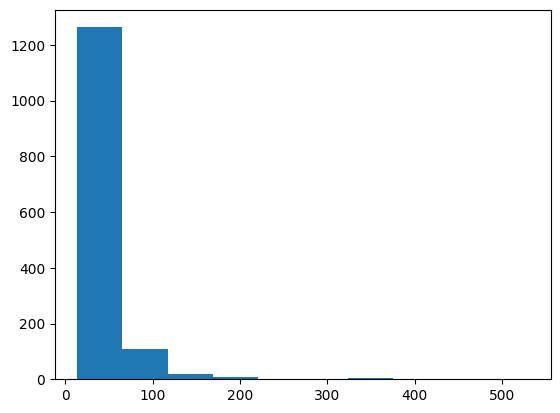

In [69]:
plt.hist(df_new_max_vol_ehull_min_vol['max_vol_cap'])

In [70]:
'JVASP-2017' in df_new_max_vol_ehull_min_vol['jid']

False

In [71]:
df_new_max_vol_ehull_min_vol

,Unnamed: 0,name,avg_voltage,voltage_profile,max_voltage,max_vol_cap,vol_capacity_profile,max_grav_cap,grav_capacity_profile,jid,...,poisson,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search,min_voltage
2,2,Li_JVASP-48119_LiMn2F5.json,3.581894,3.212631940841675;3.650526762008667;3.33120942...,4.025076,51.179342,51.179341670156504;51.17934167015651;51.179341...,16.283925,15.817002552000238;15.882059584757009;15.94765...,JVASP-48119,...,na,"[OPT-LOPTICS,JVASP-48119.zip,https://ndownload...",16,na,na,na,na,mp-763331,-F-Li-Mn,3.212632
15,15,Li_JVASP-42175_LiVF4.json,4.330079,3.6442487239837646;3.631939649581909;3.8410894...,5.154451,42.169496,42.16949561206411;42.16949561206411;42.1694956...,13.151501,12.512258908890612;12.552935473261204;12.59387...,JVASP-42175,...,na,"[OPT-LOPTICS,JVASP-42175.zip,https://ndownload...",12,na,na,na,na,mp-780539,-F-Li-V,3.631940
20,20,Li_JVASP-119357_Li2Mn3TeO8.json,3.282684,3.0047123432159424;3.054805040359497;3.0539267...,3.891480,36.671350,36.67135006280895;36.67135006280895;36.6713500...,7.952453,7.714142328303391;7.729584452449287;7.74508852...,JVASP-119357,...,na,[],14,na,na,na,na,mp-755971,-Li-Mn-O-Te,3.004712
37,37,Li_JVASP-140321_LiNd2RuO6.json,2.894476,2.7797048091888428;2.804586172103882;2.8118584...,3.126359,45.968590,45.968589939548835;45.968589939548835;45.96858...,6.887461,6.802525222042231;6.814530420419332;6.82657806...,JVASP-140321,...,na,[],20,na,na,na,na,mp-1211080,-Li-Nd-O-Ru,2.779705
40,40,Li_JVASP-111963_LiVF4.json,3.981115,3.625145673751831;3.618274450302124;3.62022519...,4.495332,42.367363,42.367362858371756;42.367362858371756;42.36736...,13.151501,12.512258908890612;12.552935473261204;12.59387...,JVASP-111963,...,na,[],24,na,na,na,na,mp-757195,-F-Li-V,3.601448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7450,7450,Li_JVASP-119591_LiCo2P2O8.json,4.435289,4.246318101882935;4.393021821975708;4.47881484...,4.623000,66.287588,66.28758795767037;66.28758795767037;66.2875879...,21.645913,21.287904411299998;21.405917452781978;21.52524...,JVASP-119591,...,na,[],26,na,na,na,na,mp-1176782,-Co-Li-O-P,4.246318
7452,7452,Li_JVASP-43192_Li2Co3WO8.json,3.860573,4.173327207565308;4.232928991317749;4.25491452...,5.062396,41.878579,41.8785792116586;41.87857921165859;41.87857921...,6.844063,6.666812473017969;6.678343027901987;6.68991353...,JVASP-43192,...,na,"[OPT-LOPTICS,JVASP-43192.zip,https://ndownload...",28,na,na,na,na,mp-775180,-Co-Li-O-W,2.781467
7456,7456,Li_JVASP-119318_Li2CoNi3O8.json,4.452673,4.997974395751953;4.84534215927124;4.457109212...,4.997974,42.754733,42.75473284008914;42.754732840089154;42.754732...,9.206936,8.889012394004919;8.909522655328447;8.93012778...,JVASP-119318,...,na,[],14,na,na,na,na,mp-752703,-Co-Li-Ni-O,4.179734
7463,7463,Li_JVASP-1843_LiHoSe2.json,1.983914,1.3704659938812256;1.4175755977630615;1.388835...,3.253549,61.346177,61.34617662270898;61.346176622708974;61.346176...,10.349087,10.158500139236196;10.185295924451077;10.21223...,JVASP-1843,...,0.25,"[FD-ELAST,JVASP-1843.zip,https://ndownloader.f...",4,46.76,28.97,2.203,na,mp-15796,-Ho-Li-Se,1.370466


In [105]:
df_new_max_vol_ehull[df_new_max_vol_ehull.jid=='JVASP-2017']['optb88vdw_bandgap']

3467    1.005
Name: optb88vdw_bandgap, dtype: float64